In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [194]:
game = pd.read_csv('HW2.csv')

In [195]:
game.info()

<class 'pandas.DataFrame'>
RangeIndex: 1946 entries, 0 to 1945
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No               1946 non-null   int64  
 1   plod               1946 non-null   float64
 2   name               1946 non-null   str    
 3   title              938 non-null    str    
 4   gender             1946 non-null   int64  
 5   culture            677 non-null    str    
 6   dateOfBirth        433 non-null    float64
 7   DateoFdeath        444 non-null    float64
 8   mother             21 non-null     str    
 9   father             26 non-null     str    
 10  heir               23 non-null     str    
 11  house              1519 non-null   str    
 12  spouse             276 non-null    str    
 13  book1              1946 non-null   int64  
 14  book2              1946 non-null   int64  
 15  book3              1946 non-null   int64  
 16  book4              1946 non-null   

In [196]:
game.head()

,S.No,plod,name,title,gender,culture,dateOfBirth,DateoFdeath,mother,father,...,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,boolDeadRelations,isPopular,popularity,isAlive
0,1,0.946,Viserys II Targaryen,NaN,1,NaN,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,...,0.0,NaN,0,0,NaN,11,1,1,0.605351,0
1,2,0.613,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,...,NaN,1.0,1,1,97.0,1,1,1,0.896321,1
2,3,0.507,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,1,NaN,0,0,0,0.267559,1
3,4,0.924,Aemma Arryn,Queen,0,NaN,82.0,105.0,NaN,NaN,...,NaN,0.0,1,1,23.0,0,0,0,0.183946,0
4,5,0.383,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,...,NaN,1.0,1,1,29.0,0,0,0,0.043478,1


In [197]:
game['name'].duplicated().sum()

np.int64(0)

## **MODEL**

In [198]:
X = game.drop('isAlive', axis=1)
y = game['isAlive']

In [199]:
y.value_counts()

isAlive
1    1451
0     495
Name: count, dtype: int64

In [200]:
def split_data(X, y, size=0.8):
    np.random.seed(42)

    X_train, X_test = [], []
    y_train, y_test = [], []

    for classes in np.unique(y):
        class_idx = np.where(y == classes)[0]
        idx = np.random.permutation(len(class_idx))
        split = int(len(class_idx) * size)

        X_train.append(X.iloc[idx[:split]])
        X_test.append(X.iloc[idx[split:]])
        y_train.append(y.iloc[idx[:split]])
        y_test.append(y.iloc[idx[split:]])

    X_train = pd.concat(X_train).reset_index(drop=True)
    X_test = pd.concat(X_test).reset_index(drop=True)
    y_train = pd.concat(y_train).reset_index(drop=True)
    y_test = pd.concat(y_test).reset_index(drop=True)

    return X_train, X_test, y_train, y_test

In [201]:
X_train, X_test, y_train, y_test = split_data(X, y)

for val in [X_train, X_test, y_train, y_test]:
    print(val.shape)

(1556, 29)
(390, 29)
(1556,)
(390,)


In [202]:
y_train.value_counts()

isAlive
1    1212
0     344
Name: count, dtype: int64

In [203]:
game['isAlive'].value_counts()

isAlive
1    1451
0     495
Name: count, dtype: int64

In [204]:
class Node:
    def __init__(self, gini=0, num_samples=0, num_samples_per_class=None, predicted_class=None, feature_index=None, threshold=None, left=None, right=None):
        self.gini = gini
        self.num_samples = num_samples
        self.num_samples_per_class = num_samples_per_class
        self.predicted_class = predicted_class
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right

class DTCART:
    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.tree_ = None
        self.classes_ = None
        self.n_classes_ = None
        self.n_features_ = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).ravel()

        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)
        self.n_features_ = X.shape[1]

        class_to_idx = {cls: idx for idx, cls in enumerate(self.classes_)}
        y_indexed = np.array([class_to_idx[cls] for cls in y], dtype=int)

        self.tree_ = self._grow_tree(X, y_indexed, depth=0)
        return self

    def _gini(self, y):
        m = len(y)
        if m == 0:
            return 0.0
        
        counts = np.bincount(y, minlength=self.n_classes_)
        probs = counts / m

        return 1.0 - np.sum(probs ** 2)

    def _best_split(self, X, y):
        m, n = X.shape
        if m <= 1:
            return None, None

        parent_gini = self._gini(y)
        best_gini = parent_gini + 1
        best_idx, best_thr = None, None

        for feature_idx in range(n):
            sorted_indices = np.argsort(X[:, feature_idx])
            X_sorted = X[sorted_indices, feature_idx]
            y_sorted = y[sorted_indices]

            num_left = np.zeros(self.n_classes_, dtype=int)
            num_right = np.bincount(y_sorted, minlength=self.n_classes_)

            for i in range(1, m):
                c = y_sorted[i - 1]
                num_left[c] += 1
                num_right[c] -= 1

                if X_sorted[i] == X_sorted[i - 1]:
                    continue

                n_left = i
                n_right = m - i

                if n_left < self.min_samples_leaf or n_right < self.min_samples_leaf:
                    continue

                gini_left = 1.0 - np.sum((num_left / n_left) ** 2)
                gini_right = 1.0 - np.sum((num_right / n_right) ** 2)

                gini = (n_left * gini_left + n_right * gini_right) / m

                if gini < best_gini:
                    best_gini = gini
                    best_idx = feature_idx
                    best_thr = (X_sorted[i] + X_sorted[i - 1]) / 2
        return best_idx, best_thr

    
    def _grow_tree(self, X, y, depth=0):
        num_samples_per_class = np.bincount(y, minlength=self.n_classes_)
        predicted_class = np.argmax(num_samples_per_class)

        node = Node(
            gini = self._gini(y),
            num_samples = len(y),
            num_samples_per_class=num_samples_per_class,
            predicted_class=predicted_class

        )

        if (self.max_depth is not None and depth >= self.max_depth) or \
           len(y) < self.min_samples_split or \
           len(np.unique(y)) == 1:
            return node
        
        feature_idx, threshold  = self._best_split(X, y)

        if feature_idx is None:
            return node

        left_mask = X[:, feature_idx] <= threshold
        right_mask = ~left_mask

        if np.sum(left_mask) < self.min_samples_leaf or \
           np.sum(right_mask) < self.min_samples_leaf:
            return node
            
        node.feature_index = feature_idx
        node.threshold = threshold

        node.left = self._grow_tree(X[left_mask], y[left_mask], depth + 1)
        node.right = self._grow_tree(X[right_mask], y[right_mask], depth + 1)

        return node


    def predict(self, X):
        X = np.asarray(X)
        return np.array([self._predict_sample(x) for x in X])

    def _predict_sample(self, x):
        node = self.tree_
        while node.left is not None and node.right is not None:
            if x[node.feature_index] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return self.classes_[node.predicted_class]

    def predict_proba(self, X):
        X = np.asarray(X)
        return np.array([self._predict_proba_sample(x) for x in X])

    def _predict_proba_sample(self, x):
        node = self.tree_
        while node.left is not None and node.right is not None:
            if x[node.feature_index] <= node.threshold:
                node = node.left
            else:
                node = node.right

        probs = node.num_samples_per_class / node.num_samples
        return probs

    def score(self, X, y):
        y = np.asarray(y).ravel()
        predictions = self.predict(X)
        return np.mean(predictions == y)

    def print_tree(self, node=None, indent=''):
        if node is None:
            node = self.tree_

        info = f'Gini {node.gini} - Sample {node.num_samples} - '
        info += f'Class {self.classes_[node.predicted_class]}'

        if node.left is None and node.right is None:
            print(indent + 'leaf: ' + info)
        else:
            feature_name = f'Feature {node.feature_index}'
            print(indent + f'Split {feature_name} <= {node.threshold}' + info)
            print(indent + 'left')
            self.print_tree(node.left, indent + ' ')
            print(indent + 'right')
            self.print_tree(node.right, indent + ' ')
        

#### dummy

In [205]:
if __name__ == "__main__":
    print("=" * 60)
    print("DECISION TREE CART CLASSIFICATION - NUMPY ONLY")
    print("=" * 60)
    
    # Generate synthetic dataset
    np.random.seed(42)
    
    # Dataset 1: XOR-like problem (non-linear)
    print("\n1. Testing dengan XOR-like dataset:")
    print("-" * 40)
    
    X_xor = np.array([
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1],
        [0.1, 0.1],
        [0.1, 0.9],
        [0.9, 0.1],
        [0.9, 0.9]
    ])
    y_xor = np.array([0, 1, 1, 0, 0, 1, 1, 0])  # XOR pattern
    
    # Train model
    clf_xor = DTCART(max_depth=3)
    clf_xor.fit(X_xor, y_xor)
    
    print("Tree structure:")
    clf_xor.print_tree()
    
    print(f"\nPredictions: {clf_xor.predict(X_xor)}")
    print(f"Actual:      {y_xor}")
    print(f"Accuracy:    {clf_xor.score(X_xor, y_xor):.2%}")
    
    # Dataset 2: Iris-like dataset (3 kelas)
    print("\n\n2. Testing dengan multi-class dataset:")
    print("-" * 40)
    
    # Buat 3 cluster sederhana
    n_samples = 150
    X_multi = np.vstack([
        np.random.randn(n_samples//3, 2) + [0, 0],    # Kelas 0
        np.random.randn(n_samples//3, 2) + [5, 0],    # Kelas 1
        np.random.randn(n_samples//3, 2) + [2.5, 5]   # Kelas 2
    ])
    y_multi = np.array([0]*50 + [1]*50 + [2]*50)
    
    # Shuffle
    idx = np.random.permutation(n_samples)
    X_multi, y_multi = X_multi[idx], y_multi[idx]
    
    # Split train-test manual
    split = int(0.8 * n_samples)
    X_train, X_test = X_multi[:split], X_multi[split:]
    y_train, y_test = y_multi[:split], y_multi[split:]
    
    # Train
    clf_multi = DTCART(max_depth=5, min_samples_leaf=2)
    clf_multi.fit(X_train, y_train)
    
    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")
    print(f"Number of classes: {clf_multi.n_classes_}")
    print(f"Features: {clf_multi.n_features_}")
    
    train_acc = clf_multi.score(X_train, y_train)
    test_acc = clf_multi.score(X_test, y_test)
    
    print(f"\nTrain Accuracy: {train_acc:.2%}")
    print(f"Test Accuracy:  {test_acc:.2%}")
    
    # Prediksi probabilitas
    print(f"\nContoh predict_proba untuk 3 sample pertama:")
    probs = clf_multi.predict_proba(X_test[:3])
    for i, (x, prob) in enumerate(zip(X_test[:3], probs)):
        print(f"  Sample {i}: x={x}, probs={prob}, pred={np.argmax(prob)}")
    
    # Dataset 3: Edge cases
    print("\n\n3. Testing edge cases:")
    print("-" * 40)
    
    # Single sample
    X_single = np.array([[1.0, 2.0]])
    y_single = np.array([0])
    clf_single = DTCART()
    clf_single.fit(X_single, y_single)
    print(f"Single sample - Prediction: {clf_single.predict(X_single)}")
    
    # Semua label sama
    X_same = np.random.randn(10, 2)
    y_same = np.zeros(10, dtype=int)
    clf_same = DTCART()
    clf_same.fit(X_same, y_same)
    print(f"All same label - Prediction: {clf_same.predict(X_same[:3])}")
    
    # Test dengan y sebagai list (bukan numpy array)
    print("\n4. Testing dengan input list:")
    print("-" * 40)
    X_list = [[0, 0], [0, 1], [1, 0], [1, 1]]
    y_list = [0, 1, 1, 0]
    clf_list = DTCART(max_depth=2)
    clf_list.fit(X_list, y_list)
    print(f"List input - Predictions: {clf_list.predict(X_list)}")
    print(f"List input - Accuracy: {clf_list.score(X_list, y_list):.2%}")
    
    print("\n" + "=" * 60)
    print("TESTING COMPLETE!")
    print("=" * 60)

DECISION TREE CART CLASSIFICATION - NUMPY ONLY

1. Testing dengan XOR-like dataset:
----------------------------------------
Tree structure:
Split Feature 0 <= 0.05Gini 0.5 - Sample 8 - Class 0
left
 Split Feature 1 <= 0.5Gini 0.5 - Sample 2 - Class 0
 left
  leaf: Gini 0.0 - Sample 1 - Class 0
 right
  leaf: Gini 0.0 - Sample 1 - Class 1
right
 Split Feature 1 <= 0.05Gini 0.5 - Sample 6 - Class 0
 left
  leaf: Gini 0.0 - Sample 1 - Class 1
 right
  Split Feature 0 <= 0.95Gini 0.48 - Sample 5 - Class 0
  left
   leaf: Gini 0.5 - Sample 4 - Class 0
  right
   leaf: Gini 0.0 - Sample 1 - Class 0

Predictions: [0 1 1 0 0 0 0 0]
Actual:      [0 1 1 0 0 1 1 0]
Accuracy:    75.00%


2. Testing dengan multi-class dataset:
----------------------------------------
Training samples: 120
Test samples: 30
Number of classes: 3
Features: 2

Train Accuracy: 100.00%
Test Accuracy:  93.33%

Contoh predict_proba untuk 3 sample pertama:
  Sample 0: x=[4.81465857 3.13273481], probs=[0. 1. 0.], pred=1
  Sa

In [206]:
best_depth = None
best_acc = 0
accuracy = []

for depth in [2,3,4,5,6,7,8,9,10,11]:
    model = DTCART(max_depth=depth)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = np.mean(pred == y_test)
    # model.print_tree() 

    print(f'Depth: {depth} - Accuracy: {acc:.4f}')

    if acc > best_acc:
        best_acc = acc
        best_depth = depth
print(f'Best Depth: {best_depth} - Accuracy: {best_acc:.4f}')

Depth: 2 - Accuracy: 0.9333
Depth: 3 - Accuracy: 0.9333
Depth: 4 - Accuracy: 0.9333
Depth: 5 - Accuracy: 0.9333
Depth: 6 - Accuracy: 0.9333
Depth: 7 - Accuracy: 0.9333
Depth: 8 - Accuracy: 0.9333
Depth: 9 - Accuracy: 0.9333
Depth: 10 - Accuracy: 0.9333
Depth: 11 - Accuracy: 0.9333
Best Depth: 2 - Accuracy: 0.9333


In [207]:

model = DTCART(max_depth=best_depth)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [208]:
def evaluate(y_true, y_pred, title='Train'):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    classes = np.unique(y_true)

    accuracy = []
    precision = []
    recall = []
    f1 = []

    for i in classes:
        tp = np.sum((y_true == i) & (y_pred == i))
        fp = np.sum((y_true != i) & (y_pred == i))
        fn = np.sum((y_true == i) & (y_pred != i))

        p = tp / (tp + fp) if (tp + fp) > 0 else 0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0
        f = 2 * (p * r) / (p + r) if (p + r) > 0 else 0

        precision.append(p)
        recall.append(r)
        f1.append(f)

    accuracy = np.mean(y_true == y_pred)
    precision = np.mean(precision)
    recall = np.mean(recall)
    f1 = np.mean(f1)

    print(f'\nEvaluasi Data {title}')
    print(f'Accuracy    : {accuracy:.4%}')
    print(f'Precision   : {precision:.4%}')
    print(f'Recall      : {recall:.4%}')
    print(f'F1          : {f1:.4%}')

In [209]:
evaluate(y_train, y_pred_train)
evaluate(y_test, y_pred_test, title='Test')


Evaluasi Data Train
Accuracy    : 100.0000%
Precision   : 100.0000%
Recall      : 100.0000%
F1          : 100.0000%

Evaluasi Data Test
Accuracy    : 93.3333%
Precision   : 95.2381%
Recall      : 91.6667%
F1          : 92.6740%


In [210]:
def confusion_matrix(y_true, y_pred, title='Train'):
    classes = np.unique(y_true)
    n_classes = len(classes)

    cm = np.zeros((n_classes, n_classes))

    for i, c_true in enumerate(classes):
        for j, c_pred in enumerate(classes):
            cm[i, j] = np.sum((y_true == c_true) * (y_pred == c_pred))
    
    plt.figure(figsize=(10,8))
    plt.title(f'Confusion Matrix data {title}')
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()

In [211]:
np.unique(y_train)

array([0, 1, 2])

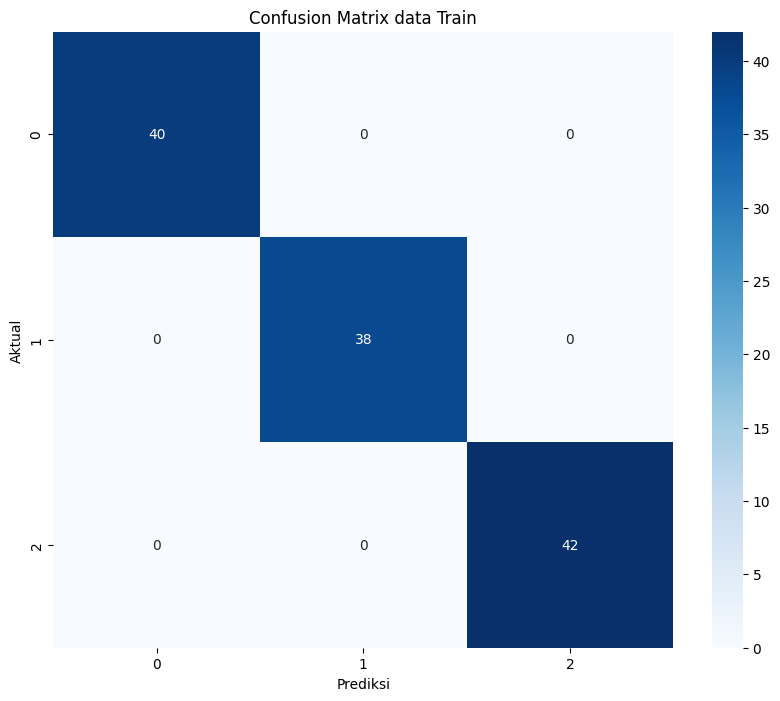

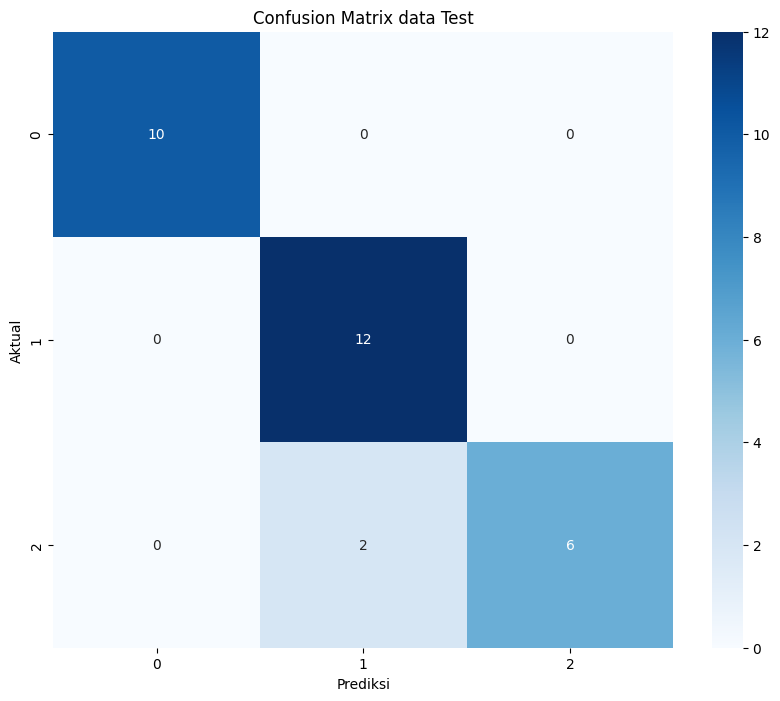

In [212]:
confusion_matrix(y_train, y_pred_train)
confusion_matrix(y_test, y_pred_test, title='Test')

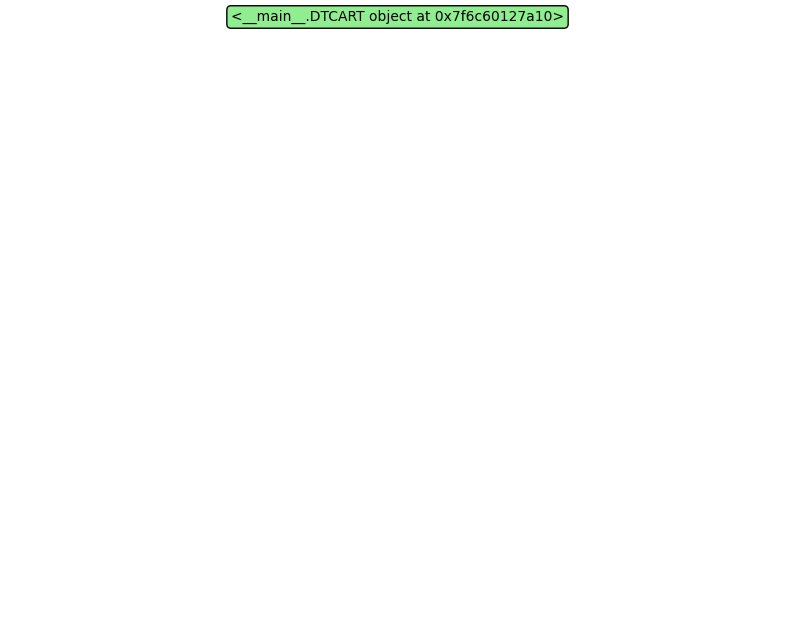

In [213]:
def visualize_tree(tree, feature_name, depth=0, x=0.5, y=1.0, dx=0.25):
    if not isinstance(tree, dict):
        plt.text(x, y, str(tree), ha='center', va='center', bbox=dict(boxstyle='round', facecolor='lightgreen'))
        return 
    
    plt.text(x, y, f'{feature_name[tree['feature_idx']]} < {tree['val']:.2f}', ha='center', va='center', bbox=dict(boxstyle='round', facecolor='lightblue'))

    visualize_tree(tree['left'], feature_name, depth + 1, x - dx / (depth + 1), y - 0.1, dx)
    plt.plot([x, x - dx / (depth + 1)], [y - 0.02, y - 0.08], 'k-')

    visualize_tree(tree['right'], feature_name, depth + 1, x + dx / (depth + 1), y - 0.1, dx)
    plt.plot([x, x + dx / (depth + 1)], [y - 0.02, y - 0.08], 'k-')

plt.figure(figsize=(10,8))
visualize_tree(model, X.columns)
plt.axis('off')
plt.show()
    